Value of the integrand is, 0.0012645110928411146

I varied the number of trapezia using the values 10, 11, 12, 13, 14, 15, 20, and 200,
and looked for where the value didn't change for the first 6 significant figures.
Doing this I found that 14 trapezia gets a fractional error of less than 6 significant figures.

Value of the second integral is, 1.7622612252632388

Using infinity and negative infinity as limits is too large. We know what the value of the integral should be.
So I used ranges of -1,1 -2,2 -3,3 -4,4 -5,5 to see which one is most accurate compared to the known value and it was -2,2



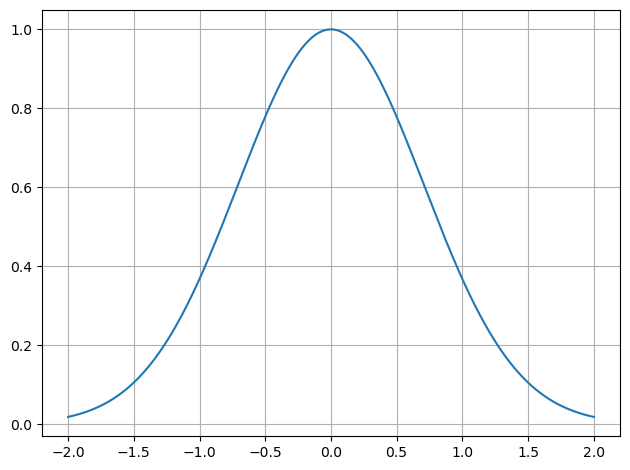

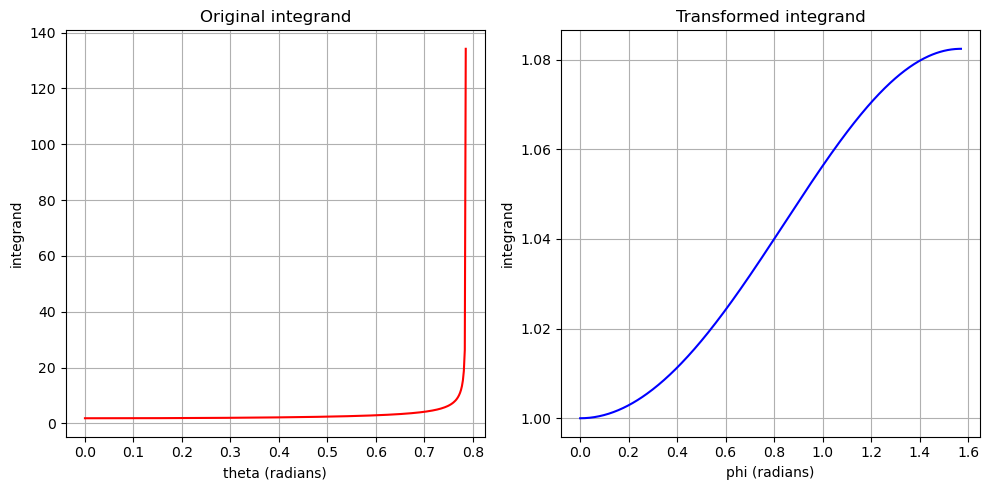

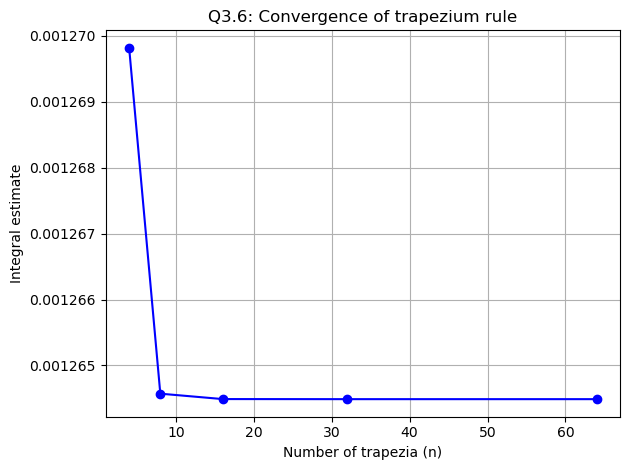

Converged at n = 64 integral ≈ 0.0012644892676672204
Amplitude = 0.0 degrees,  T/T0 = 1.0
Amplitude = 10.0 degrees,  T/T0 = 1.001907
Amplitude = 20.0 degrees,  T/T0 = 1.007669
Amplitude = 30.0 degrees,  T/T0 = 1.017409
Amplitude = 40.0 degrees,  T/T0 = 1.031341
Amplitude = 50.0 degrees,  T/T0 = 1.049783
Amplitude = 60.0 degrees,  T/T0 = 1.073182
Amplitude = 70.0 degrees,  T/T0 = 1.102145
Amplitude = 80.0 degrees,  T/T0 = 1.137493
Amplitude = 90.0 degrees,  T/T0 = 1.180341


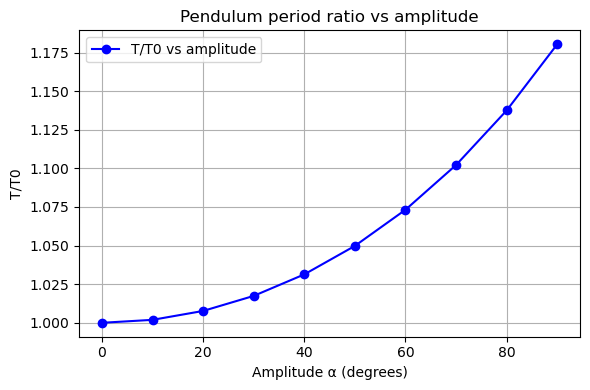

Accurate value of T/T0 for α = 90°: 1.1803405990160964
Cannot reach requested accuracy with 512 trapezia.
Trapezium rule result: 1.9999937250705768
SciPy quad result: 2.0
Estimated error from quad: 2.220446049250313e-14
Difference between methods = 6.274929423177866e-06
Relative error (%) = 0.0003137464711588933


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

#3.1 - writing the integrand
def trap0(f, a, b, n):
    h = float(b - a) / n
    s = 0.5 * (f(a) + f(b))
    for i in range(1, n):
        s = s + f(a + i * h)
    return s * h

#3.2 - Value of the integrand
def integrand(x):
    return (((x**4) * (1 - x)**4) / (1 + x**2))

value = trap0(integrand, 0, 1, 10)
print("Value of the integrand is,", value)

#3.3 - How many trapezia (guess)
print("""
I varied the number of trapezia using the values 10, 11, 12, 13, 14, 15, 20, and 200,
and looked for where the value didn't change for the first 6 significant figures.
Doing this I found that 14 trapezia gets a fractional error of less than 6 significant figures.
""")

#3.4 - Another integral
def integrand_two(x):
    return np.exp(-x**2)  # integral 2, has a known value of sqrt(pi) which is 1.77245385091

value_new = trap0(integrand_two, -2, 2, 10)
print("Value of the second integral is,", value_new)
print("""
Using infinity and negative infinity as limits is too large. We know what the value of the integral should be.
So I used ranges of -1,1 -2,2 -3,3 -4,4 -5,5 to see which one is most accurate compared to the known value and it was -2,2
""")

#3.5 - Plotting the integrand
x = np.linspace(-2, 2, 500)
integrand_plot = integrand_two(x)
plt.plot(x, integrand_plot)
plt.grid(True)
plt.tight_layout()
plt.show()

#3.5 - Visualising the effect of the variable transformation
alpha_rads = np.radians(45)

def f_theta(theta, alpha_rads):
    return 1 / np.sqrt(np.cos(theta) - np.cos(alpha_rads))

def f_phi(phi, alpha_rads):
    return 1 / np.sqrt(1 - (np.sin(alpha_rads / 2)**2) * (np.sin(phi)**2))

theta = np.linspace(0, alpha_rads * 0.9999, 400)
phi = np.linspace(0, np.pi / 2, 400)

f_theta_vals = f_theta(theta, alpha_rads)
f_phi_vals = f_phi(phi, alpha_rads)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(theta, f_theta_vals, 'r')
plt.xlabel('theta (radians)')
plt.ylabel('integrand')
plt.title('Original integrand')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(phi, f_phi_vals, 'b')
plt.xlabel('phi (radians)')
plt.ylabel('integrand')
plt.title('Transformed integrand')
plt.grid(True)

plt.tight_layout()
plt.show()

#3.6 - Adaptive trapezium rule
def trap1(f, a, b, delta=1e-6, maxtraps=512):
    n = 8
    inew = trap0(f, a, b, n)
    iold = -inew
    while (np.abs(inew - iold) > delta * np.abs(inew)):
        iold = inew
        n = 2 * n
        if n > maxtraps:
            print("Cannot reach requested accuracy with", maxtraps, "trapezia.")
            break
        inew = trap0(f, a, b, n)
    return inew

# testing trap1 to show it's more accurate (bonus)
def integrand_test(x):
    return (x**4 * (1 - x)**4) / (1 + x**2)

a, b = 0, 1
delta = 1e-6  # still using 6 sigfig

n = 4  # was gonna do 8 but you couldn't really see it clearly so used 4 instead
I_old = trap0(integrand_test, a, b, n)
n_values = [n]
I_values = [I_old]

# doubling n just like in trap1
while True:
    n *= 2
    I_new = trap0(integrand_test, a, b, n)
    n_values.append(n)
    I_values.append(I_new)
    if abs(I_new - I_old) < delta * abs(I_new):
        break  # convergence reached, same rule as trap1
    I_old = I_new

plt.figure()
plt.plot(n_values, I_values, 'bo-')
plt.xlabel('Number of trapezia (n)')
plt.ylabel('Integral estimate')
plt.title('Q3.6: Convergence of trapezium rule')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Converged at n =", n, "integral ≈", I_new)

#Period ratio T/T0 vs amplitude
def T_ratio(alpha_rads, delta=1e-6):
    f = lambda phi: f_phi(phi, alpha_rads)
    integral_value = trap1(f, 0, np.pi / 2, delta)
    return (2 / np.pi) * integral_value

alphas_deg = np.linspace(0, 90, 10)
ratios = []

for alpha_deg in alphas_deg:
    alpha_rads = np.radians(alpha_deg)
    ratio = T_ratio(alpha_rads)
    ratios.append(ratio)
    print("Amplitude =", alpha_deg, "degrees,  T/T0 =", round(ratio, 6))

plt.figure(figsize=(6, 4))
plt.plot(alphas_deg, ratios, 'bo-', label='T/T0 vs amplitude')
plt.xlabel('Amplitude α (degrees)')
plt.ylabel('T/T0')
plt.title('Pendulum period ratio vs amplitude')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#3.7 - finding an accurate value for alpha=90 degrees
alpha_90 = np.radians(90)
ratio_90 = T_ratio(alpha_90, delta=1e-7)
print("Accurate value of T/T0 for α = 90°:", ratio_90)

# bonus - comparing my trap rule to SciPy quad
def test_func(x):
    return np.sin(x)

a, b = 0, np.pi

I_trap = trap1(test_func, a, b, delta=1e-6)
print("Trapezium rule result:", I_trap)

I_quad, error = quad(test_func, a, b)
print("SciPy quad result:", I_quad)
print("Estimated error from quad:", error)

print("Difference between methods =", abs(I_trap - I_quad))
print("Relative error (%) =", abs(I_trap - I_quad) / I_quad * 100)

Total area =  1.00215
Estimated total area under Gaussian = 1.0022
Estimated probability within ±2σ = 0.382


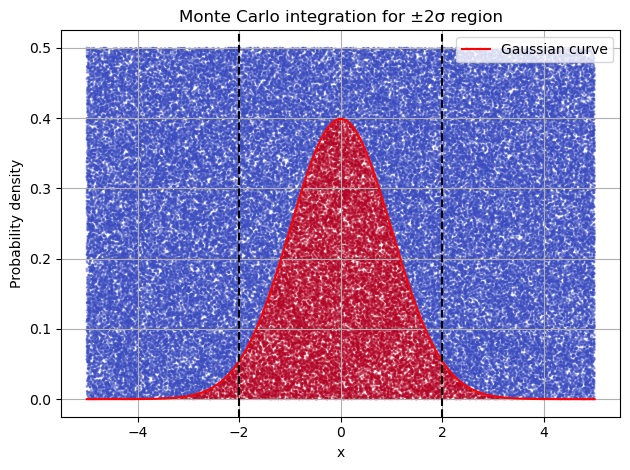

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Gaussian (mean=0, sd=1)
def gaussian(x):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

# Range that covers most of the curve,any higher just samples empty space
x_min, x_max = -5, 5
y_min, y_max = 0, 0.5

N = 100000  # number of random points ("darts")

# Random x and y points
x_rand = np.random.uniform(x_min, x_max, N)
y_rand = np.random.uniform(y_min, y_max, N)

y_gauss = gaussian(x_rand)

# Points that fall under the curve
hits = np.sum(y_rand < y_gauss)

# Area of the box
area_box = (x_max - x_min) * (y_max - y_min)

# Estimate total area (should be ~1)
area_total = area_box * hits / N
print("Total area = ",area_total)

# Estimate probability for |x|<2
mask = (x_rand >= -2) & (x_rand <= 2)
hits_2sigma = np.sum((y_rand < y_gauss) & mask)
area_2sigma = (4) * (y_max - y_min)
prob_2sigma = area_2sigma * hits_2sigma / N

print("Estimated total area under Gaussian =", round(area_total, 4))
print("Estimated probability within ±2σ =", round(prob_2sigma, 4))


x = np.linspace(x_min, x_max, 400)
plt.plot(x, gaussian(x), 'r-', label='Gaussian curve')
plt.scatter(x_rand, y_rand, s=1, c=(y_rand < y_gauss), cmap='coolwarm', alpha=0.4)
plt.axvline(-2, color='k', linestyle='--')
plt.axvline(2, color='k', linestyle='--')
plt.xlabel('x')
plt.ylabel('Probability density')
plt.title('Monte Carlo integration for ±2σ region')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()